# ADTA 5940 — FARS 2023 Exploratory Data Analysis
**Team D | Aman Gill | Musa Sayeed**

---
## Target Variables Explained + Notebook Glossary

Alcohol Impairment (IS_ALCOHOL_IMPAIRED)
What it is: A binary flag (1 or 0) indicating if the driver was legally impaired (BAC ≥ 0.08 g/dL).
How we derived it: We took the ALC_RES (Alcohol Result) from the Person file, converted the whole numbers (like 8, 15) into the standard decimal BAC, and flagged anyone at or above the federal legal limit.
How we work with it: Because 64% of drivers aren't tested, we only calculate impairment rates based on the tested population to avoid 'watering down' the results with unknowns.
2. Speeding Involvement (IS_SPEEDING)
What it is: A binary flag (1 or 0) indicating if speeding was a contributing factor in the crash.
How we derived it: We used the SPEEDREL column from the Vehicle file. We collapsed multiple specific codes (like 'Racing', 'Exceeded Limit', and 'Too Fast for Conditions') into a single 'Yes' (1).
How we work with it: Unlike alcohol, speeding is officer-reported for almost every crash (only ~6% missing), so we can use it across nearly the entire dataset.

**Sections:**
- **Section 0** — Setup & Imports
- **Section 1** — Data Loading & Schema Overview
- **Section 2** — Data Preparation & Merging
- **Section 3** — Missing Value Analysis
- **Section 4** — EDA: Alcohol Impairment (`IS_ALCOHOL_IMPAIRED`)
- **Section 5** — EDA: Speeding (`IS_SPEEDING`)
- **Section 6** — Cross-Target Analysis

> **One-Hot Encoding Note:** We acknowledge that one-hot encoding as a project requirement, when time comes to worh with the categorical variables for modeling. The purpose of this notebook is EDA.

---
## Section 0 — Setup & Imports

Standard imports for data manipulation and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot Styling ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

# Color constants (used consistently across all plots)
COLOR_ALCOHOL  = '#E05A5A'   # Red  — alcohol impairment
COLOR_SPEEDING = '#4A90D9'   # Blue — speeding
COLOR_BOTH     = '#9B59B6'   # Purple — both combined
COLOR_NEUTRAL  = '#95A5A6'   # Grey  — baseline / not involved

print('Setup complete.')

Setup complete.


---
## Section 1 — Data Loading & Schema Overview

### The Six Files We Are Working With

NHTSA structures FARS as a relational database. Each fatal crash generates records across multiple linked files. We work with **six files** for 2023:

| File | Grain | Key Purpose |
|------|-------|-------------|
| `accident.csv` | 1 row per crash | Crash context: time, location, weather, road type |
| `person_sample.xlsx` | 1 row per person involved | Driver demographics, BAC, injury, restraint use |
| `vehicle_sample.xlsx` | 1 row per vehicle involved | Speeding, speed limit, road type, prior violations |
| `acc_aux.csv` | 1 row per crash | Pre-computed NHTSA analytical flags (crash level) |
| `per_aux.csv` | 1 row per person | Pre-computed NHTSA flags (person level) |
| `veh_aux.csv` | 1 row per vehicle | Pre-computed NHTSA flags (vehicle level)

**Why the aux files?** The aux (auxiliary) files are NHTSA's own pre-derived analytical flags. For example, `A_POSBAC` flags whether a crash involved a |
positive BAC driver, and `A_SPCRA` flags speed-related crashes. We use these as **validation checkpoints** — if our own derived binary targets (`IS_ALCOHOL_IMPAIRED`, `IS_SPEEDING`) align with the aux flags, we can trust our derivation logic.

In [ ]:
# ── Load All Six Files ────────────────────────────────────────────────────────
# Adjusted paths to point to the /content/sample_data/ directory
path = 'sample_data/'

acc     = pd.read_csv(path + 'accident.csv',  low_memory=False)
acc_aux = pd.read_csv(path + 'acc_aux.csv',   low_memory=False)
per_aux = pd.read_csv(path + 'per_aux.csv',   low_memory=False)
veh_aux = pd.read_csv(path + 'veh_aux.csv',   low_memory=False)
per     = pd.read_csv(path + 'person.csv',    low_memory=False)
veh     = pd.read_csv(path + 'vehicle.csv',   low_memory=False)

print('=== FILE SHAPES ===')
files = {
    'accident.csv':          acc,
    'acc_aux.csv':           acc_aux,
    'per_aux.csv':           per_aux,
    'veh_aux.csv':           veh_aux,
    'person.csv':            per,
    'vehicle.csv':           veh,
}
for name, df in files.items():
    print(f'  {name:<28} {df.shape[0]:>6} rows × {df.shape[1]:>3} cols')

=== FILE SHAPES ===
  accident.csv                  37654 rows ×  80 cols
  acc_aux.csv                   37654 rows ×  44 cols
  per_aux.csv                   92400 rows ×  25 cols
  veh_aux.csv                   58319 rows ×  19 cols
  person.csv                    92400 rows × 126 cols
  vehicle.csv                   58319 rows × 203 cols


### Compiled Column Inventory & Chart-Variable Relationships

#### Target Variables:
- **IS_ALCOHOL_IMPAIRED** — derived from `ALC_RES` (person file)
- **IS_SPEEDING** — derived from `SPEEDREL` (vehicle file)

#### All Columns Used:

| Column | File | What It Is |
|:---|:---|:---|
| **ALC_RES** | person | Raw BAC value → becomes `IS_ALCOHOL_IMPAIRED` |
| **SPEEDREL** | vehicle | Speed factor codes → becomes `IS_SPEEDING` |
| **PER_TYP** | person | Filters to drivers only |
| **AGE** | person | Driver age |
| **SEX** | person | Driver sex |
| **HOUR** | accident | Hour of crash |
| **DAY_WEEK** | accident | Day of week |
| **LGT_COND** | accident | Lighting condition |
| **RUR_URB** | accident | Rural vs urban |
| **VSPD_LIM** | vehicle | Posted speed limit |
| **VTRAFWAY** | vehicle | Trafficway type |
| **VSURCOND** | vehicle | Road surface condition |
| **PREV_DWI** | vehicle | Prior DWI convictions |
| **PREV_SPD** | vehicle | Prior speeding violations |
| **A_POSBAC** | acc_aux | Aux validation — alcohol flag |
| **A_SPCRA** | acc_aux | Aux validation — speed flag |

#### What Chart Uses What:

| Chart | Section | Columns Involved |
|:---|:---:|:---|
| Missing value bar chart | 3 | All key columns |
| Impairment by hour (line) | 4A | `IS_ALCOHOL_IMPAIRED` + `HOUR` |
| Impairment by day of week (bar) | 4B | `IS_ALCOHOL_IMPAIRED` + `DAY_WEEK` |
| Impairment by age group (bar) | 4C | `IS_ALCOHOL_IMPAIRED` + `AGE` |
| Impairment by sex (bar) | 4D | `IS_ALCOHOL_IMPAIRED` + `SEX` |
| Impairment by lighting (bar) | 4E | `IS_ALCOHOL_IMPAIRED` + `LGT_COND` |
| Impairment by rural/urban (bar) | 4F | `IS_ALCOHOL_IMPAIRED` + `RUR_URB` |
| Speeding overall (pie) | 5A | `IS_SPEEDING` |
| Speeding by speed limit (bar) | 5B | `IS_SPEEDING` + `VSPD_LIM` |
| Speeding by trafficway (bar) | 5C | `IS_SPEEDING` + `VTRAFWAY` |
| Speeding by surface condition (bar) | 5D | `IS_SPEEDING` + `VSURCOND` |
| Speeding by prior violations (bar) | 5E | `IS_SPEEDING` + `PREV_SPD` + `PREV_DWI` |
| Speeding by hour + day (line+bar) | 5F | `IS_SPEEDING` + `HOUR` + `DAY_WEEK` |
| Alcohol rate by speeding status (bar) | 6 | `IS_ALCOHOL_IMPAIRED` + `IS_SPEEDING` |
| Co-occurrence composition (bar) | 6 | `IS_ALCOHOL_IMPAIRED` + `IS_SPEEDING` |

### Key Variables — Quick Reference

Below are the variables most central to our two research targets. Full glossary is in the concept paper.

**Alcohol Target (`IS_ALCOHOL_IMPAIRED`)** — derived from `ALC_RES` in the person file:
- `ALC_RES`: Blood Alcohol Concentration result, stored as a whole number (e.g., `8` = 0.08 g/dL, `15` = 0.15 g/dL)
- Special codes 995–999 = not tested, refused, unknown — these are treated as missing, not zero
- Legal impairment threshold: BAC ≥ 0.08 g/dL → stored as `ALC_RES >= 8`

**Speeding Target (`IS_SPEEDING`)** — derived from `SPEEDREL` in the vehicle file:
- `SPEEDREL`: Whether speed was a contributing factor in the crash
- `0` = No | `2` = Too Fast for Conditions | `3` = Racing | `4` = Exceeded Limit | `5` = Too Fast (other)
- `8` = Not Reported | `9` = Unknown — treated as missing
- Any value 1–5 is classified as speeding involved

> **Note:** The 2023 FARS encoding for SPEEDREL was expanded from a binary (0/1) to a more granular set of codes. In our 2023 data, values 2–5 represent the speeding categories. Our binary derivation captures all of them.

In [ ]:
# ── Preview key columns ───────────────────────────────────────────────────────
print('--- ACCIDENT: Temporal & Environmental Columns ---')
print(acc[['ST_CASE','STATENAME','HOUR','DAY_WEEK','DAY_WEEKNAME',
            'RUR_URB','LGT_COND','WEATHER','FATALS']].head(3).to_string())

print('\n--- PERSON: Driver & BAC Columns ---')
print(per[['ST_CASE','VEH_NO','PER_TYP','AGE','SEX','ALC_RES','ALC_STATUS','DRINKING']].head(3).to_string())

print('\n--- VEHICLE: Speeding & Road Columns ---')
print(veh[['ST_CASE','VEH_NO','SPEEDREL','VSPD_LIM','VTRAFWAY','VSURCOND','PREV_DWI','PREV_SPD']].head(3).to_string())

--- ACCIDENT: Temporal & Environmental Columns ---
   ST_CASE STATENAME  HOUR  DAY_WEEK DAY_WEEKNAME  RUR_URB  LGT_COND  WEATHER  FATALS
0    10001   Alabama    22         4    Wednesday        1         2        1       1
1    10002   Alabama     2         2       Monday        1         2        1       1
2    10003   Alabama    22         7     Saturday        1         2        1       1

--- PERSON: Driver & BAC Columns ---
   ST_CASE  VEH_NO  PER_TYP  AGE  SEX  ALC_RES  ALC_STATUS  DRINKING
0    10001       1        1   33    1      996           0         0
1    10002       1        1   32    2      217           2         1
2    10003       1        1   21    2      148           2         0

--- VEHICLE: Speeding & Road Columns ---
   ST_CASE  VEH_NO  SPEEDREL  VSPD_LIM  VTRAFWAY  VSURCOND  PREV_DWI  PREV_SPD
0    10001       1         0        55         1         1         0         1
1    10002       1         0        45         1         1         0         0
2    10003  

---
## Section 2 — Data Preparation & Merging

### Step 1: Filter to Drivers

The person file contains everyone involved in the crash — drivers, passengers, pedestrians, cyclists, etc. For both of our research targets, we are specifically interested in **drivers** (the person at the wheel).

FARS identifies person type via `PER_TYP`:
- `1` = Driver of a motor vehicle in transport ← **we keep only this**
- `2` = Passenger
- `3` = Pedestrian
- `5` = Bicyclist
- etc.

Filtering to `PER_TYP == 1` ensures our alcohol and speeding analyses reflect the person in control of the vehicle.

In [ ]:
# ── Step 1: Isolate Drivers ───────────────────────────────────────────────────
drivers = per[per['PER_TYP'] == 1].copy()

print(f'Total persons in sample:  {len(per):>6}')
print(f'Drivers (PER_TYP == 1):   {len(drivers):>6}')
print(f'Non-drivers excluded:      {len(per) - len(drivers):>6}')
print(f'\nPER_TYP breakdown:')
ptype_map = {1:'Driver', 2:'Passenger', 3:'Pedestrian', 5:'Bicyclist', 6:'Other'}
for k, v in per['PER_TYP'].value_counts().items():
    print(f'  {ptype_map.get(k, k)}: {v}')

Total persons in sample:   92400
Drivers (PER_TYP == 1):    57939
Non-drivers excluded:       34461

PER_TYP breakdown:
  Driver: 57939
  Passenger: 24658
  Bicyclist: 7730
  Other: 1191
  Pedestrian: 456
  8: 244
  4: 68
  9: 60
  10: 42
  7: 12


### Step 2: Derive `IS_ALCOHOL_IMPAIRED` from `ALC_RES`

**Why not use the `DRINKING` column?** The person file has a column called `DRINKING` (officer-reported drinking, Yes/No). We deliberately avoid it because it does not measure crossing the legal impairment threshold — an officer can mark 'Yes' for someone with a BAC of 0.03, well below the 0.08 legal limit. Using `ALC_RES` with the federal threshold gives us a legally and methodologically precise binary target.

**BAC Cleaning Logic:**
- FARS stores BAC as a whole number: `8` = 0.08 g/dL, `15` = 0.15 g/dL, etc.
- Special placeholder codes `995–999` (not tested, refused, pending, unknown) are **set to NaN** — they are not zero
- `IS_ALCOHOL_IMPAIRED = 1` if `ALC_RES >= 8` (i.e., BAC ≥ 0.08 g/dL)
- `IS_ALCOHOL_IMPAIRED = 0` if `ALC_RES < 8` (tested, below threshold)
- `IS_ALCOHOL_IMPAIRED = NaN` if test was not conducted or result unknown

> **Important:** All impairment rates in Section 4 are computed *among tested drivers only*. Including NaN rows in a rate calculation would deflate the impairment rate and misrepresent reality.

In [ ]:
# ── Step 2: Clean BAC & Create Alcohol Target ─────────────────────────────────
SPECIAL_CODES = [995, 996, 997, 998, 999]  # Not tested / refused / unknown

drivers['BAC_RAW'] = pd.to_numeric(drivers['ALC_RES'], errors='coerce')
drivers.loc[drivers['BAC_RAW'].isin(SPECIAL_CODES), 'BAC_RAW'] = np.nan

# Binary: 1 if >= 0.08, 0 if below, NaN if untested
drivers['IS_ALCOHOL_IMPAIRED'] = np.where(
    drivers['BAC_RAW'].isna(), np.nan,
    (drivers['BAC_RAW'] >= 8).astype(int)
)

# Summary
total   = len(drivers)
tested  = drivers['BAC_RAW'].notna().sum()
missing = total - tested
impaired = (drivers['IS_ALCOHOL_IMPAIRED'] == 1).sum()

print('=== BAC / Alcohol Impairment Summary ===')
print(f'  Total drivers:              {total:>6}')
print(f'  Tested (valid BAC result):  {tested:>6}  ({tested/total*100:.1f}% of drivers)')
print(f'  Not tested / unknown:       {missing:>6}  ({missing/total*100:.1f}% of drivers)')
print(f'  Impaired (BAC >= 0.08):     {impaired:>6}  ({impaired/tested*100:.1f}% of TESTED drivers)')
print(f'\nNote: ~{missing/total*100:.0f}% missing BAC reflects real-world testing limitations.')
print('All impairment rates hereafter are computed among tested drivers only.')

=== BAC / Alcohol Impairment Summary ===
  Total drivers:               57939
  Tested (valid BAC result):   20955  (36.2% of drivers)
  Not tested / unknown:        36984  (63.8% of drivers)
  Impaired (BAC >= 0.08):       7403  (35.3% of TESTED drivers)

Note: ~64% missing BAC reflects real-world testing limitations.
All impairment rates hereafter are computed among tested drivers only.


### Step 3: Derive `IS_SPEEDING` from `SPEEDREL`

The vehicle file's `SPEEDREL` column captures whether speed was a contributing factor, and in what way. In 2023 FARS data, the coding breaks out several speeding sub-types:

| Code | Meaning |
|------|---------|
| 0 | No — speed not a factor |
| 2 | Yes — Too Fast for Conditions |
| 3 | Yes — Racing |
| 4 | Yes — Exceeded Posted Limit |
| 5 | Yes — Too Fast (other) |
| 8 | Not Reported |
| 9 | Unknown |

We collapse codes 2–5 into `IS_SPEEDING = 1`. Codes 8 and 9 become NaN. Code 0 becomes `IS_SPEEDING = 0`.

In [ ]:
# ── Step 3: Create Speeding Target ───────────────────────────────────────────
veh['SPEEDREL_CLEAN'] = pd.to_numeric(veh['SPEEDREL'], errors='coerce')

veh['IS_SPEEDING'] = np.where(
    veh['SPEEDREL_CLEAN'].isin([8, 9]), np.nan,
    np.where(veh['SPEEDREL_CLEAN'].between(1, 5), 1, 0)
)

# Subcategory breakdown
spd_codes = {0:'No',2:'Too Fast for Conditions',3:'Racing',4:'Exceeded Limit',5:'Too Fast (other)',8:'Not Reported',9:'Unknown'}
print('=== SPEEDREL Distribution ===')
for k, v in veh['SPEEDREL_CLEAN'].value_counts().sort_index().items():
    pct = v / len(veh) * 100
    label = spd_codes.get(int(k), str(k))
    print(f'  {int(k)} ({label:<28}): {v:>5} ({pct:.1f}%)')

valid_spd = veh.dropna(subset=['IS_SPEEDING'])
print(f'\nSpeeding involved: {valid_spd["IS_SPEEDING"].sum():.0f} of {len(valid_spd)} valid records ({valid_spd["IS_SPEEDING"].mean()*100:.1f}%)')

=== SPEEDREL Distribution ===
  0 (No                          ): 43835 (75.2%)
  2 (Too Fast for Conditions     ):   140 (0.2%)
  3 (Racing                      ):  4094 (7.0%)
  4 (Exceeded Limit              ):  4483 (7.7%)
  5 (Too Fast (other)            ):  2026 (3.5%)
  8 (Not Reported                ):   364 (0.6%)
  9 (Unknown                     ):  3377 (5.8%)

Speeding involved: 10743 of 54578 valid records (19.7%)


### Step 4: Merge the Files

Our merge strategy follows the logical hierarchy of the FARS database:

1. **Start with drivers** (filtered person file) — this is our unit of analysis
2. **Inner join with vehicle** on `ST_CASE + VEH_NO` — links each driver to their specific vehicle (and its SPEEDREL)
3. **Left join with accident** on `ST_CASE` — adds crash-level context (time, weather, location) to every driver row

We use an **inner join** for vehicle to ensure we only keep drivers that have a matching vehicle record. We use a **left join** for accident because every crash should have an accident record — if somehow it doesn't, we still keep the driver rather than losing the row.

In [ ]:
# ── Step 4: Merge ─────────────────────────────────────────────────────────────
# Select only the vehicle columns we need
veh_cols = ['ST_CASE','VEH_NO','IS_SPEEDING','SPEEDREL','VSPD_LIM',
            'VTRAFWAY','VSURCOND','PREV_DWI','PREV_SPD','BODY_TYP','NUMOCCS']
veh_slim = veh[[c for c in veh_cols if c in veh.columns]].copy()

# Select only the accident columns we need
acc_cols = ['ST_CASE','HOUR','DAY_WEEK','DAY_WEEKNAME','MONTH','LGT_COND',
            'LGT_CONDNAME','WEATHER','WEATHERNAME','RUR_URB','RUR_URBNAME',
            'FUNC_SYS','FUNC_SYSNAME','FATALS']
acc_slim = acc[[c for c in acc_cols if c in acc.columns]].copy()

# Merge chain
master = (
    drivers
    .merge(veh_slim, on=['ST_CASE','VEH_NO'], how='inner')  # driver ↔ vehicle
    .merge(acc_slim, on='ST_CASE',            how='left')   # + crash context
)

print(f'Drivers before merge: {len(drivers)}')
print(f'Master df after merge: {master.shape[0]} rows × {master.shape[1]} cols')

# Identify available columns (handling suffixes from merge)
hour_col = 'HOUR' if 'HOUR' in master.columns else 'HOUR_y'
rur_col = 'RUR_URB' if 'RUR_URB' in master.columns else 'RUR_URB_y'

print(f'\nKey target columns present: IS_ALCOHOL_IMPAIRED, IS_SPEEDING')
print(master[['ST_CASE','IS_ALCOHOL_IMPAIRED','IS_SPEEDING', hour_col, 'DAY_WEEK', rur_col]].head(5).to_string())

Drivers before merge: 57939
Master df after merge: 57939 rows × 150 cols

Key target columns present: IS_ALCOHOL_IMPAIRED, IS_SPEEDING
   ST_CASE  IS_ALCOHOL_IMPAIRED  IS_SPEEDING  HOUR_y  DAY_WEEK  RUR_URB_y
0    10001                  NaN          0.0      22         4          1
1    10002                  1.0          0.0       2         2          1
2    10003                  1.0          1.0      22         7          1
3    10004                  1.0          1.0      19         6          1
4    10005                  0.0          1.0      14         6          1


### Step 5: Validate Against NHTSA Aux Flags

This is where the aux files earn their place. NHTSA's own analysts pre-compute summary flags at the crash level in `acc_aux.csv`. Two flags are directly relevant:

- `A_POSBAC` — crash involved a driver with positive BAC: `1`=Yes, `2`=No, `3`=Unknown
- `A_SPCRA` — speed was a contributing factor: `1`=Yes, `2`=No

We compare these against our own derived flags as a sanity check. Agreement means our derivation logic is sound.

In [ ]:
# ── Step 5: Aux Validation ────────────────────────────────────────────────────
# Crash-level alcohol flag from aux
alc_aux_counts = acc_aux['A_POSBAC'].value_counts().sort_index()
spd_aux_counts  = acc_aux['A_SPCRA'].value_counts().sort_index()

print('=== A_POSBAC (acc_aux) — Crash-level positive BAC flag ===')
posbac_map = {1:'Yes – positive BAC driver', 2:'No', 3:'Unknown'}
for k, v in alc_aux_counts.items():
    print(f'  {k} ({posbac_map.get(k,k)}): {v} crashes ({v/len(acc_aux)*100:.1f}%)')

print('\n=== A_SPCRA (acc_aux) — Speed-related crash flag ===')
spcra_map = {1:'Yes – speed related', 2:'No'}
for k, v in spd_aux_counts.items():
    print(f'  {k} ({spcra_map.get(k,k)}): {v} crashes ({v/len(acc_aux)*100:.1f}%)')

# Our driver-level speeding rate for comparison
our_spd_rate = master['IS_SPEEDING'].mean()
aux_spd_rate = (acc_aux['A_SPCRA'] == 1).mean()
print(f'\nOur IS_SPEEDING rate (driver level):  {our_spd_rate*100:.1f}%')
print(f'Aux A_SPCRA rate (crash level):       {aux_spd_rate*100:.1f}%')
print('(Slight difference is expected — driver vs crash grain, and our sample is 25k not full dataset)')

=== A_POSBAC (acc_aux) — Crash-level positive BAC flag ===
  1 (Yes – positive BAC driver): 7403 crashes (19.7%)
  2 (No): 6031 crashes (16.0%)
  3 (Unknown): 24220 crashes (64.3%)

=== A_SPCRA (acc_aux) — Speed-related crash flag ===
  1 (Yes – speed related): 10541 crashes (28.0%)
  2 (No): 27113 crashes (72.0%)

Our IS_SPEEDING rate (driver level):  19.7%
Aux A_SPCRA rate (crash level):       28.0%
(Slight difference is expected — driver vs crash grain, and our sample is 25k not full dataset)


---
## Section 3 — Missing Value Analysis

Before diving into findings, we need to understand where data is missing and why. In FARS, missingness is rarely random — it often reflects real-world constraints like testing refusals, pending results, or officer discretion. Understanding the missing data pattern is part of understanding the dataset.

=== Missing Values in Key Columns ===
                     Missing  Pct Missing
BAC_RAW                36984         63.8
IS_ALCOHOL_IMPAIRED    36984         63.8
IS_SPEEDING             3375          5.8
VSPD_LIM                   0          0.0
AGE                        0          0.0
SEX                        0          0.0
HOUR_y                     0          0.0
DAY_WEEK                   0          0.0
LGT_COND                   0          0.0
WEATHER                    0          0.0
RUR_URB_y                  0          0.0
PREV_DWI                   0          0.0
PREV_SPD                   0          0.0


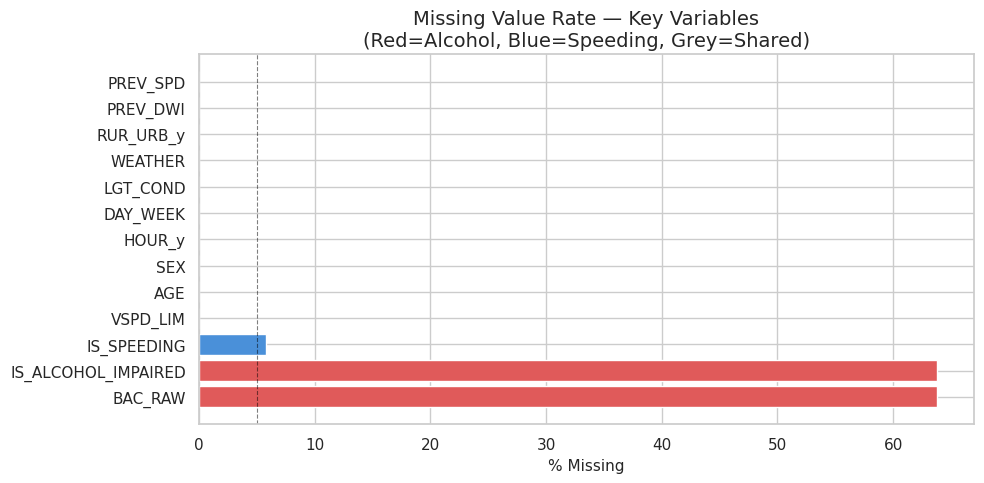


Note: High BAC missingness (~65%) is a known FARS limitation.
All alcohol rates in Section 4 are among TESTED drivers only.


In [ ]:
# ── Missing Value Summary ─────────────────────────────────────────────────────
# Identify actual column names after merge suffixes
hour_col = 'HOUR' if 'HOUR' in master.columns else 'HOUR_y'
rur_col = 'RUR_URB' if 'RUR_URB' in master.columns else 'RUR_URB_y'

key_vars = ['BAC_RAW','IS_ALCOHOL_IMPAIRED','IS_SPEEDING',
            'VSPD_LIM','AGE','SEX', hour_col, 'DAY_WEEK', 'LGT_COND',
            'WEATHER', rur_col, 'PREV_DWI', 'PREV_SPD']

miss = pd.DataFrame({
    'Missing': master[key_vars].isna().sum(),
    'Pct Missing': (master[key_vars].isna().mean() * 100).round(1)
}).sort_values('Pct Missing', ascending=False)

print('=== Missing Values in Key Columns ===')
print(miss.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLOR_ALCOHOL if 'IMPAIR' in c or 'BAC' in c
          else COLOR_SPEEDING if 'SPEED' in c or 'SPD' in c or 'SPRL' in c
          else COLOR_NEUTRAL for c in miss.index]
ax.barh(miss.index, miss['Pct Missing'], color=colors)
ax.set_xlabel('% Missing')
ax.set_title('Missing Value Rate — Key Variables\n(Red=Alcohol, Blue=Speeding, Grey=Shared)')
ax.axvline(5, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='5% threshold')
plt.tight_layout()
plt.show()
print('\nNote: High BAC missingness (~65%) is a known FARS limitation.')
print('All alcohol rates in Section 4 are among TESTED drivers only.')

---
## Section 4 — EDA: Alcohol Impairment

**Target variable:** `IS_ALCOHOL_IMPAIRED` (1 = BAC ≥ 0.08 g/dL, 0 = below threshold, NaN = not tested)

All rates below are computed among **tested drivers only** (~35% of our sample — a common limitation in FARS research). The findings in this section speak to the shape of the risk, not absolute counts.

**Research questions addressed:** RQ1 (demographic & behavioral factors) and RQ2 (temporal & environmental factors)

### 4A — Hour of Day: The U-Shaped Pattern

The most striking temporal signal in the data is a pronounced U-shape when we plot impairment rates by hour. Rates are highest in the late-night and early-morning hours (midnight through 3 AM), crash to their lowest point mid-morning, and gradually climb again through the evening.

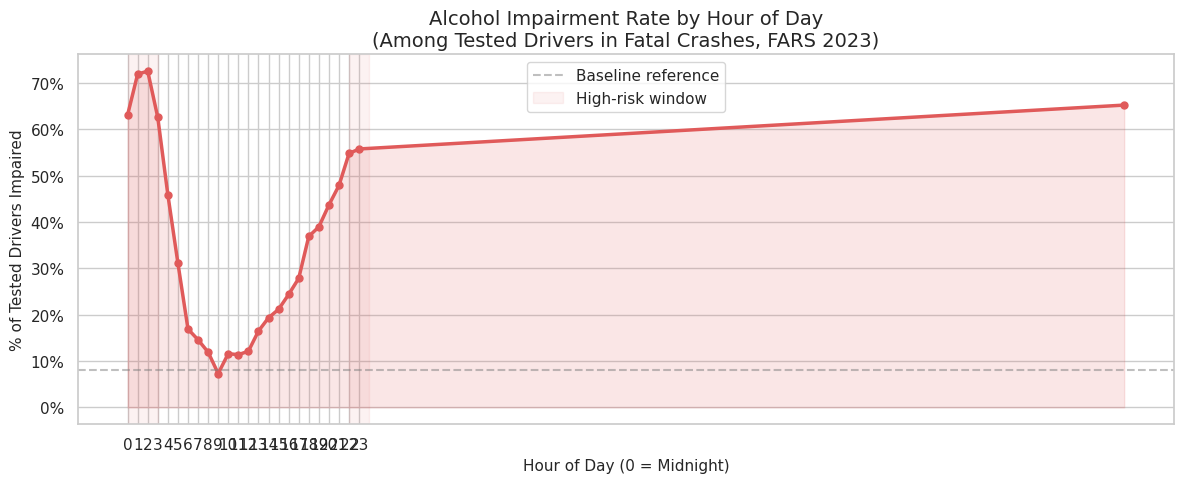

Peak impairment:   Hour 02:00 — 72.5%
Lowest impairment: Hour 09:00 — 7.3%
Ratio (peak/low):  9.9x


In [ ]:
# ── 4A: Impairment Rate by Hour ───────────────────────────────────────────────
# Identify actual hour column name after merge suffixes
hour_col = 'HOUR' if 'HOUR' in master.columns else 'HOUR_y'

hour_data = (
    master.groupby(hour_col)['IS_ALCOHOL_IMPAIRED']
    .agg(rate='mean', n='count')
    .dropna()
    .reset_index()
)
hour_data.columns = ['HOUR', 'rate', 'n']
hour_data = hour_data[hour_data['n'] >= 10]  # Remove hours with very few observations

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hour_data['HOUR'], hour_data['rate'] * 100,
        color=COLOR_ALCOHOL, linewidth=2.5, marker='o', markersize=5)
ax.fill_between(hour_data['HOUR'], hour_data['rate'] * 100, alpha=0.15, color=COLOR_ALCOHOL)
ax.axhline(0.08 * 100, color='grey', linestyle='--', alpha=0.5, label='Baseline reference')
ax.set_xlabel('Hour of Day (0 = Midnight)')
ax.set_ylabel('% of Tested Drivers Impaired')
ax.set_title('Alcohol Impairment Rate by Hour of Day\n(Among Tested Drivers in Fatal Crashes, FARS 2023)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(range(0, 24))
# Shade the high-risk window
ax.axvspan(22, 24, alpha=0.08, color=COLOR_ALCOHOL, label='High-risk window')
ax.axvspan(0, 3,  alpha=0.08, color=COLOR_ALCOHOL)
ax.legend()
plt.tight_layout()
plt.show()

# Key stats
peak_hour = hour_data.loc[hour_data['rate'].idxmax()]
low_hour  = hour_data.loc[hour_data['rate'].idxmin()]
print(f'Peak impairment:   Hour {int(peak_hour.HOUR):02d}:00 — {peak_hour.rate*100:.1f}%')
print(f'Lowest impairment: Hour {int(low_hour.HOUR):02d}:00 — {low_hour.rate*100:.1f}%')
print(f'Ratio (peak/low):  {peak_hour.rate/low_hour.rate:.1f}x')

### 4B — Day of Week: The Weekend Effect

Alcohol-related fatal crashes cluster heavily on weekends. Sunday shows the highest impairment rate, reflecting the tail of Saturday night activity — many 'Sunday' crashes in FARS occur in the early morning hours that follow Saturday night.

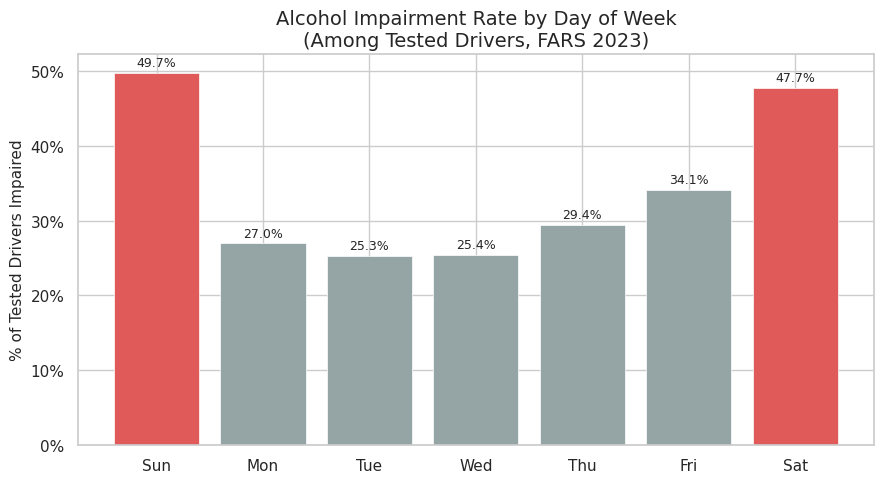

Weekend (Sat+Sun) avg: 48.7%
Weekday (Mon-Fri) avg: 28.2%


In [ ]:
# ── 4B: Impairment Rate by Day of Week ────────────────────────────────────────
dow_map = {1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat'}
master['DOW_LABEL'] = master['DAY_WEEK'].map(dow_map)

dow_order = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
dow_data = (
    master.groupby('DOW_LABEL')['IS_ALCOHOL_IMPAIRED']
    .mean()
    .dropna()
    .reindex(dow_order)
    * 100
)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [COLOR_ALCOHOL if d in ['Sun','Sat'] else COLOR_NEUTRAL for d in dow_order]
ax.bar(dow_data.index, dow_data.values, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_ylabel('% of Tested Drivers Impaired')
ax.set_title('Alcohol Impairment Rate by Day of Week\n(Among Tested Drivers, FARS 2023)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (day, val) in enumerate(dow_data.items()):
    ax.text(i, val + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('Weekend (Sat+Sun) avg:', f"{dow_data[['Sat','Sun']].mean():.1f}%")
print('Weekday (Mon-Fri) avg:', f"{dow_data[['Mon','Tue','Wed','Thu','Fri']].mean():.1f}%")

### 4C — Age Groups: Young Adult Dominance

Impairment risk is strongly age-stratified. Drivers in their 20s and 30s account for the highest impairment rates among those tested. The rate declines steadily with age, dropping sharply for drivers 70 and older — consistent with lower alcohol consumption rates and possibly higher testing compliance in older cohorts.

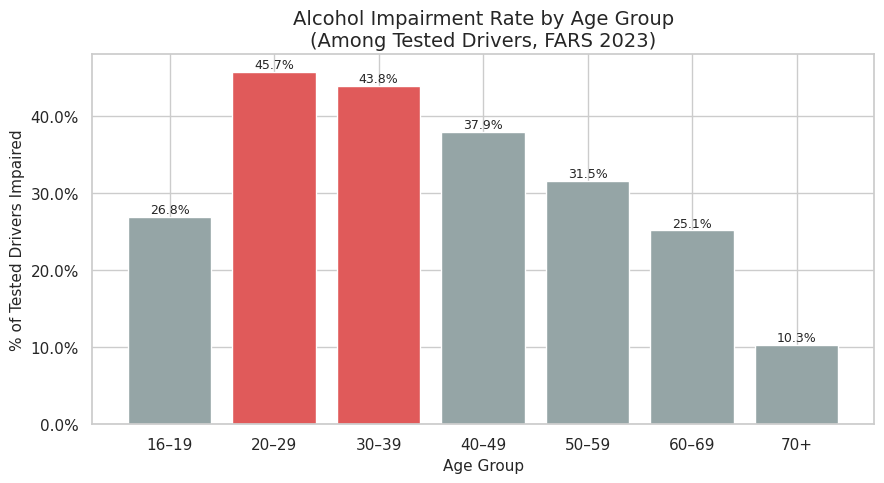

               rate     n  rate_pct
AGE_GROUP                          
16–19      0.268276  1450      26.8
20–29      0.456669  4881      45.7
30–39      0.438017  4235      43.8
40–49      0.379195  3278      37.9
50–59      0.314886  2855      31.5
60–69      0.251280  2344      25.1
70+        0.102564  1872      10.3


In [ ]:
# ── 4C: Impairment Rate by Age Group ─────────────────────────────────────────
bins   = [15, 20, 30, 40, 50, 60, 70, 120]
labels = ['16–19','20–29','30–39','40–49','50–59','60–69','70+']
master['AGE_GROUP'] = pd.cut(master['AGE'], bins=bins, labels=labels, right=False)

age_data = (
    master.groupby('AGE_GROUP', observed=True)['IS_ALCOHOL_IMPAIRED']
    .agg(rate='mean', n='count')
    .dropna()
)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [COLOR_ALCOHOL if g in ['20–29','30–39'] else COLOR_NEUTRAL for g in labels]
ax.bar(age_data.index.astype(str), age_data['rate'] * 100,
       color=bar_colors, edgecolor='white')
ax.set_xlabel('Age Group')
ax.set_ylabel('% of Tested Drivers Impaired')
ax.set_title('Alcohol Impairment Rate by Age Group\n(Among Tested Drivers, FARS 2023)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (idx, row) in enumerate(age_data.iterrows()):
    ax.text(i, row['rate'] * 100 + 0.5, f"{row['rate']*100:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(age_data.assign(rate_pct=lambda d: (d['rate']*100).round(1)).to_string())

### 4D — Sex: Male Drivers Significantly More Impaired

Male drivers in fatal crashes show a markedly higher impairment rate than female drivers. This aligns with national behavioral patterns — male drivers are involved in more alcohol-related fatal crashes both in raw counts and proportionally.

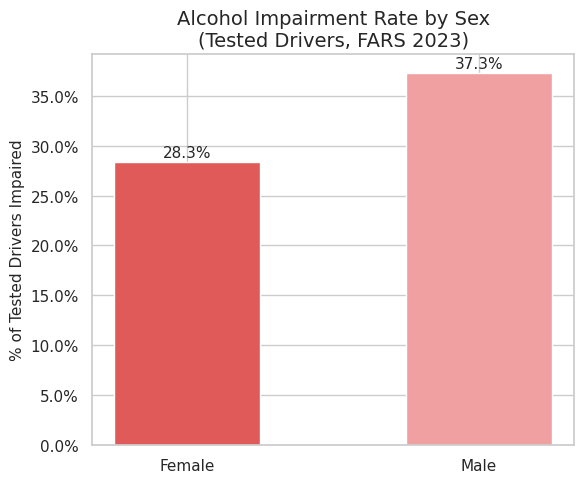

In [ ]:
# ── 4D: Impairment by Sex ─────────────────────────────────────────────────────
sex_map = {1:'Male', 2:'Female'}
master['SEX_LABEL'] = master['SEX'].map(sex_map)

sex_data = (
    master[master['SEX_LABEL'].isin(['Male','Female'])]
    .groupby('SEX_LABEL')['IS_ALCOHOL_IMPAIRED']
    .agg(rate='mean', n='count')
    .dropna()
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(sex_data.index, sex_data['rate'] * 100,
       color=[COLOR_ALCOHOL, '#F0A0A0'], edgecolor='white', width=0.5)
ax.set_ylabel('% of Tested Drivers Impaired')
ax.set_title('Alcohol Impairment Rate by Sex\n(Tested Drivers, FARS 2023)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (idx, row) in enumerate(sex_data.iterrows()):
    ax.text(i, row['rate'] * 100 + 0.5, f"{row['rate']*100:.1f}%", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### 4E — Lighting Conditions: Darkness Is a Compounding Factor

Fatal crashes occurring in dark conditions — whether lit or unlit — show substantially higher impairment rates than daylight crashes. This makes intuitive sense: alcohol impairment, nighttime hours, and reduced visibility co-occur. The temporal clustering we saw in 4A (midnight–3 AM) naturally overlaps with dark conditions.

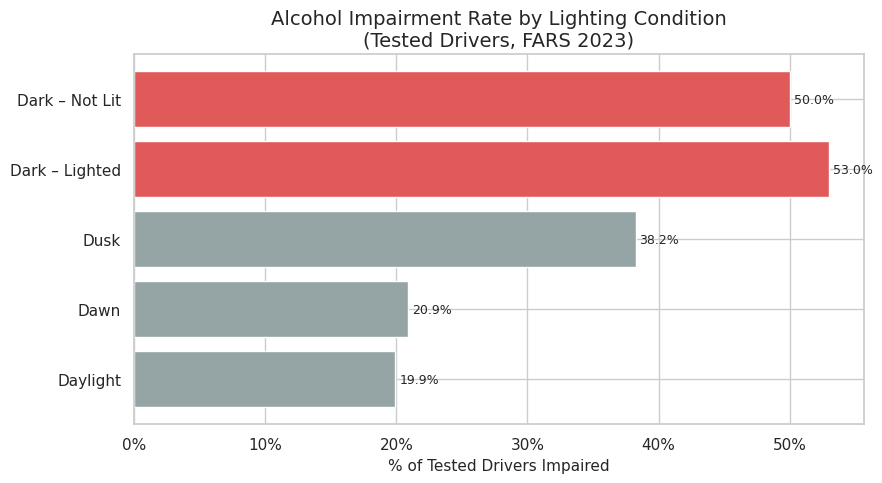

In [ ]:
# ── 4E: Impairment by Lighting Condition ──────────────────────────────────────
lgt_map = {1:'Daylight', 2:'Dark – Not Lit', 3:'Dark – Lighted',
           4:'Dawn', 5:'Dusk'}
master['LGT_LABEL'] = master['LGT_COND'].map(lgt_map)

lgt_order = ['Daylight','Dawn','Dusk','Dark – Lighted','Dark – Not Lit']
lgt_data = (
    master[master['LGT_LABEL'].isin(lgt_order)]
    .groupby('LGT_LABEL')['IS_ALCOHOL_IMPAIRED']
    .agg(rate='mean', n='count')
    .dropna()
    .reindex(lgt_order)
)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [COLOR_ALCOHOL if 'Dark' in str(l) else COLOR_NEUTRAL for l in lgt_order]
ax.barh(lgt_order, lgt_data['rate'].values * 100, color=bar_colors)
ax.set_xlabel('% of Tested Drivers Impaired')
ax.set_title('Alcohol Impairment Rate by Lighting Condition\n(Tested Drivers, FARS 2023)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for i, (idx, row) in enumerate(lgt_data.iterrows()):
    ax.text(row['rate'] * 100 + 0.3, i, f"{row['rate']*100:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 4F — Rural vs. Urban

The rural/urban split for alcohol impairment is relatively close, but urban crashes in our sample show a slightly higher impairment rate. This contrasts with the common assumption that rural roads are more dangerous for drunk driving — while rural crashes may have higher fatality severity per incident (due to longer EMS response times, higher speeds), the *rate* of alcohol involvement among tested urban drivers is comparable or slightly elevated in 2023 data.

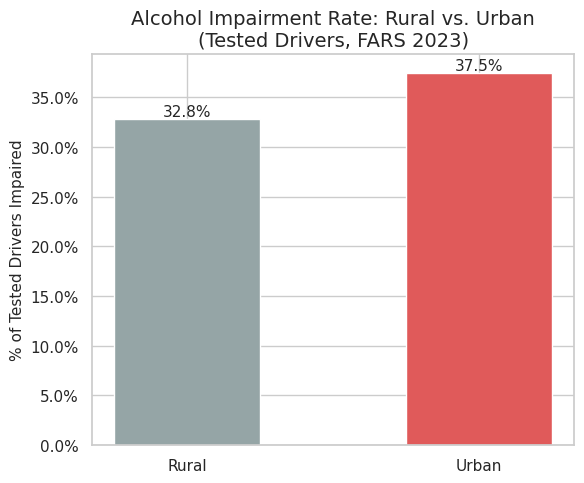

In [ ]:
# ── 4F: Impairment by Rural vs Urban ─────────────────────────────────────────
rur_map = {1:'Rural', 2:'Urban'}
# Using the renamed column from the merge (RUR_URB_y)
master['RUR_LABEL'] = master['RUR_URB_y'].map(rur_map)

rur_data = (
    master[master['RUR_LABEL'].isin(['Rural','Urban'])]
    .groupby('RUR_LABEL')['IS_ALCOHOL_IMPAIRED']
    .agg(rate='mean', n='count')
    .dropna()
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(rur_data.index, rur_data['rate'] * 100,
       color=[COLOR_NEUTRAL, COLOR_ALCOHOL], edgecolor='white', width=0.5)
ax.set_ylabel('% of Tested Drivers Impaired')
ax.set_title('Alcohol Impairment Rate: Rural vs. Urban\n(Tested Drivers, FARS 2023)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (idx, row) in enumerate(rur_data.iterrows()):
    ax.text(i, row['rate'] * 100 + 0.3, f"{row['rate']*100:.1f}%", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## Section 5 — EDA: Speeding

**Target variable:** `IS_SPEEDING` (1 = speed was a contributing factor, 0 = not, NaN = unknown/not reported)

Speeding-related analysis primarily draws from the vehicle file and accident file. This section covers road environment factors (speed limit, trafficway type, surface condition), behavioral history (prior violations), and temporal patterns.

**Research questions addressed:** RQ3 (roadway & environmental factors) and RQ4 (temporal & geographic patterns)

### 5A — Overall Speeding Involvement Rate

About 1 in 5 fatal crashes in our sample involved speeding as a contributing factor. This is the baseline we will compare all subgroup analyses against.

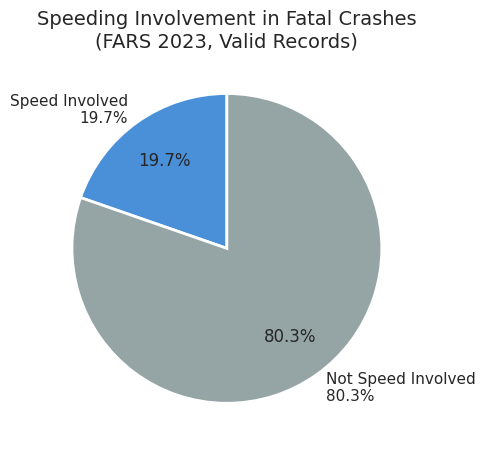

Speeding-related crashes: 10739 of 54564 (19.7%)


In [ ]:
# ── 5A: Overall Speeding Rate ─────────────────────────────────────────────────
valid_spd = master.dropna(subset=['IS_SPEEDING'])
rate = valid_spd['IS_SPEEDING'].mean()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [rate, 1 - rate],
    labels=[f'Speed Involved\n{rate*100:.1f}%', f'Not Speed Involved\n{(1-rate)*100:.1f}%'],
    colors=[COLOR_SPEEDING, COLOR_NEUTRAL],
    startangle=90, autopct='%1.1f%%', pctdistance=0.7,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Speeding Involvement in Fatal Crashes\n(FARS 2023, Valid Records)')
plt.tight_layout()
plt.show()

print(f'Speeding-related crashes: {valid_spd["IS_SPEEDING"].sum():.0f} of {len(valid_spd)} ({rate*100:.1f}%)')

### 5B — Posted Speed Limit: The Lower-Limit Paradox

Counterintuitively, crashes on lower posted speed limit roads (25–35 mph) show *higher* speeding involvement rates than crashes on highways (55–70 mph). This is not as paradoxical as it sounds — it likely reflects that lower-speed environments (residential streets, urban corridors) see more reckless or impaired driving behavior relative to their limit, while highway crashes, though higher speed overall, occur in environments where drivers may be closer to the speed limit. This is an important nuance for road safety policy.

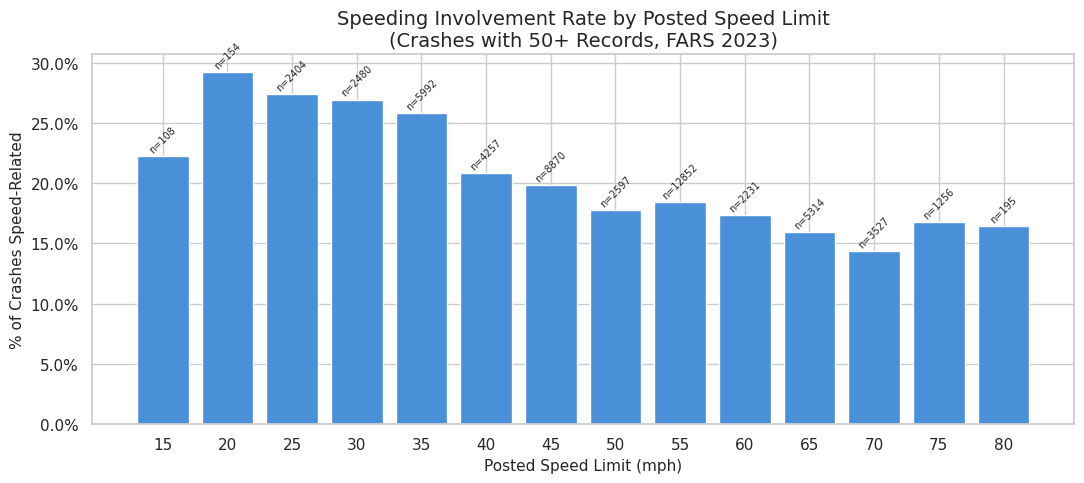

In [ ]:
# ── 5B: Speeding Rate by Posted Speed Limit ───────────────────────────────────
INVALID_LIMITS = [0, 98, 99]  # 0=not applicable, 98/99=unknown
spd_by_lim = (
    valid_spd[~valid_spd['VSPD_LIM'].isin(INVALID_LIMITS)]
    .groupby('VSPD_LIM')['IS_SPEEDING']
    .agg(rate='mean', n='count')
    .query('n >= 50')   # Only include speed limits with enough data
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(spd_by_lim['VSPD_LIM'].astype(int).astype(str),
       spd_by_lim['rate'] * 100, color=COLOR_SPEEDING, edgecolor='white')
ax.set_xlabel('Posted Speed Limit (mph)')
ax.set_ylabel('% of Crashes Speed-Related')
ax.set_title('Speeding Involvement Rate by Posted Speed Limit\n(Crashes with 50+ Records, FARS 2023)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
# Annotate sample sizes
for i, row in spd_by_lim.iterrows():
    ax.text(i, row['rate']*100 + 0.3, f"n={int(row['n'])}", ha='center', fontsize=7, rotation=45)
plt.tight_layout()
plt.show()

### 5C — Trafficway Type

The type of roadway structure plays a role in speeding involvement. One-way streets and undivided two-way roads show the highest speeding rates. These tend to be urban or semi-urban road types where speed limits are lower and drivers may feel less observed or constrained.

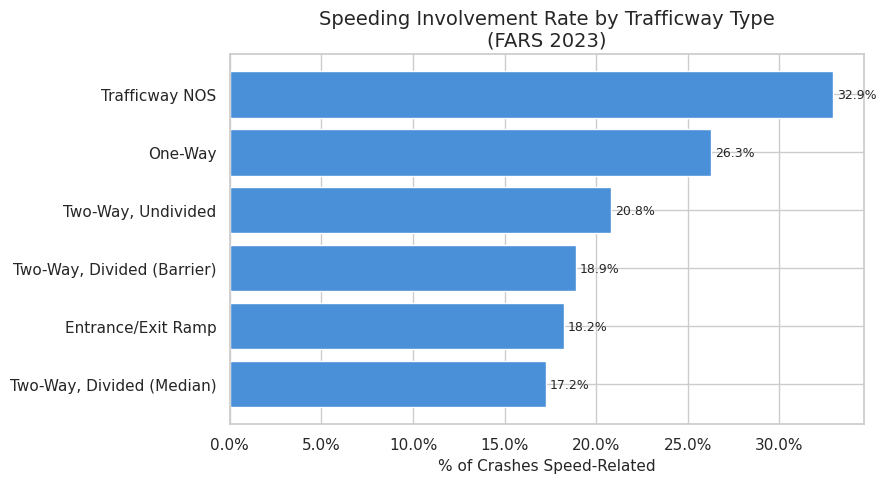

In [ ]:
# ── 5C: Speeding by Trafficway Type ──────────────────────────────────────────
traf_map = {
    1: 'Two-Way, Undivided',
    2: 'Two-Way, Divided (Median)',
    3: 'Two-Way, Divided (Barrier)',
    4: 'One-Way',
    5: 'Entrance/Exit Ramp',
    6: 'Trafficway NOS'
}
valid_spd['TRAF_LABEL'] = valid_spd['VTRAFWAY'].map(traf_map)
traf_data = (
    valid_spd[valid_spd['TRAF_LABEL'].notna()]
    .groupby('TRAF_LABEL')['IS_SPEEDING']
    .agg(rate='mean', n='count')
    .dropna()
    .query('n >= 30')
    .sort_values('rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(traf_data.index, traf_data['rate'] * 100, color=COLOR_SPEEDING)
ax.set_xlabel('% of Crashes Speed-Related')
ax.set_title('Speeding Involvement Rate by Trafficway Type\n(FARS 2023)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for i, (idx, row) in enumerate(traf_data.iterrows()):
    ax.text(row['rate']*100 + 0.2, i, f"{row['rate']*100:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5D — Surface Condition: Adverse Surfaces, Higher Speeding Involvement

This is one of the more striking findings in the speeding analysis. Crashes on icy, snowy, or otherwise adverse surface conditions show *higher* speeding involvement rates than dry-road crashes. This reinforces the concept of 'Too Fast for Conditions' — a driver on an icy road at 35 mph may be technically within the posted limit but far exceeding what is safe. FARS captures this under SPEEDREL code `2` (Too Fast for Conditions), and it shows up clearly here.

> This is also why `VSURCOND` belongs in our model — it was referenced in RQ3 of the concept paper and is confirmed here as a meaningful predictor.

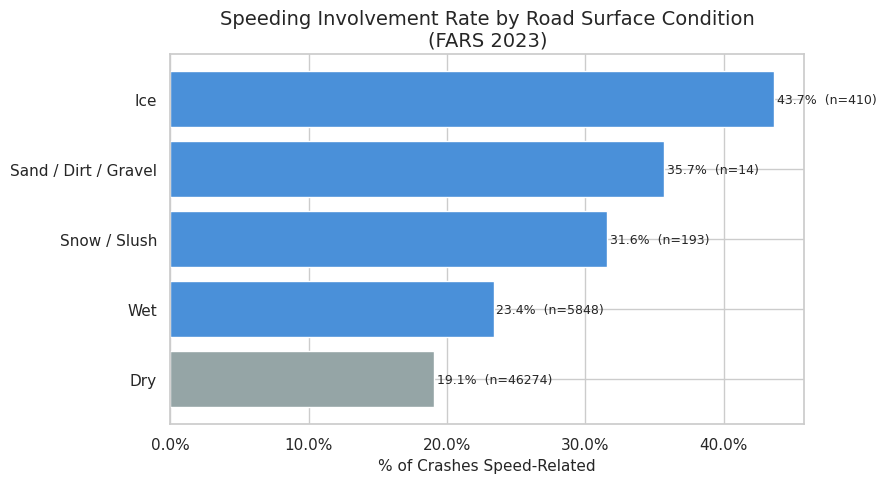

In [ ]:
# ── 5D: Speeding by Surface Condition ────────────────────────────────────────
surf_map = {
    1: 'Dry',
    2: 'Wet',
    3: 'Snow / Slush',
    4: 'Ice',
    5: 'Sand / Dirt / Gravel',
}
valid_spd['SURF_LABEL'] = valid_spd['VSURCOND'].map(surf_map)
surf_order = ['Dry','Wet','Snow / Slush','Sand / Dirt / Gravel','Ice']
surf_data = (
    valid_spd[valid_spd['SURF_LABEL'].isin(surf_order)]
    .groupby('SURF_LABEL')['IS_SPEEDING']
    .agg(rate='mean', n='count')
    .dropna()
    .reindex(surf_order)
)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [COLOR_SPEEDING if s != 'Dry' else COLOR_NEUTRAL for s in surf_order]
ax.barh(surf_data.index, surf_data['rate'] * 100, color=bar_colors)
ax.set_xlabel('% of Crashes Speed-Related')
ax.set_title('Speeding Involvement Rate by Road Surface Condition\n(FARS 2023)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for i, (idx, row) in enumerate(surf_data.iterrows()):
    if not np.isnan(row['rate']):
        ax.text(row['rate']*100 + 0.2, i, f"{row['rate']*100:.1f}%  (n={int(row['n'])})", va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5E — Prior Violation History

FARS records prior speeding violations (`PREV_SPD`) and prior DWI convictions (`PREV_DWI`) for each driver. Examining these behavioral history variables gives us a window into whether repeat offenders are overrepresented in fatal speeding crashes.

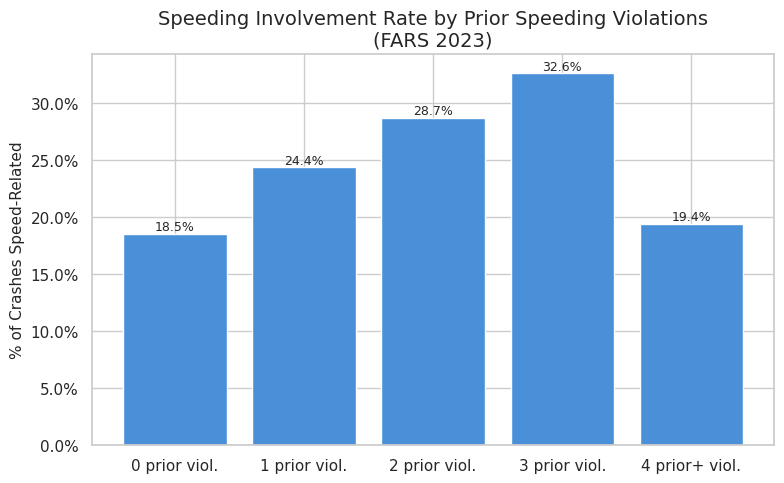

Speeding rate by prior DWI history:
  No Prior DWI: 19.3%
  Has Prior DWI: 38.0%


In [ ]:
# ── 5E: Speeding Involvement by Prior Violation History ──────────────────────
# Prior speeding violations (cap at 4+ for readability)
valid_spd = valid_spd.copy()
valid_spd['PREV_SPD_CLEAN'] = pd.to_numeric(valid_spd['PREV_SPD'], errors='coerce')
valid_spd['PREV_SPD_CLEAN'] = valid_spd['PREV_SPD_CLEAN'].clip(upper=4)  # 4 = '4 or more'

spd_by_prev = (
    valid_spd[valid_spd['PREV_SPD_CLEAN'].notna()]
    .groupby('PREV_SPD_CLEAN')['IS_SPEEDING']
    .agg(rate='mean', n='count')
    .dropna()
    .query('n >= 20')
)

fig, ax = plt.subplots(figsize=(8, 5))
labels = [f'{int(i)} prior' + (' viol.' if i < 4 else '+ viol.') for i in spd_by_prev.index]
ax.bar(labels, spd_by_prev['rate'] * 100, color=COLOR_SPEEDING, edgecolor='white')
ax.set_ylabel('% of Crashes Speed-Related')
ax.set_title('Speeding Involvement Rate by Prior Speeding Violations\n(FARS 2023)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (idx, row) in enumerate(spd_by_prev.iterrows()):
    ax.text(i, row['rate']*100 + 0.3, f"{row['rate']*100:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Prior DWI
valid_spd['PREV_DWI_CLEAN'] = pd.to_numeric(valid_spd['PREV_DWI'], errors='coerce')
valid_spd['HAS_DWI'] = (valid_spd['PREV_DWI_CLEAN'] >= 1).astype('Int64')
valid_spd.loc[valid_spd['PREV_DWI_CLEAN'].isin([99, 998]), 'HAS_DWI'] = pd.NA
dwi_data = valid_spd.groupby('HAS_DWI')['IS_SPEEDING'].mean().dropna()
print('Speeding rate by prior DWI history:')
for k, v in dwi_data.items():
    label = 'Has Prior DWI' if k == 1 else 'No Prior DWI'
    print(f'  {label}: {v*100:.1f}%')

### 5F — Temporal Pattern: Does Speeding Mirror Alcohol?

We know alcohol impairment peaks at night. Does speeding follow the same pattern? Plotting speeding involvement by hour of day lets us see whether the two targets share a temporal signature — which would reinforce the case for modeling them together.

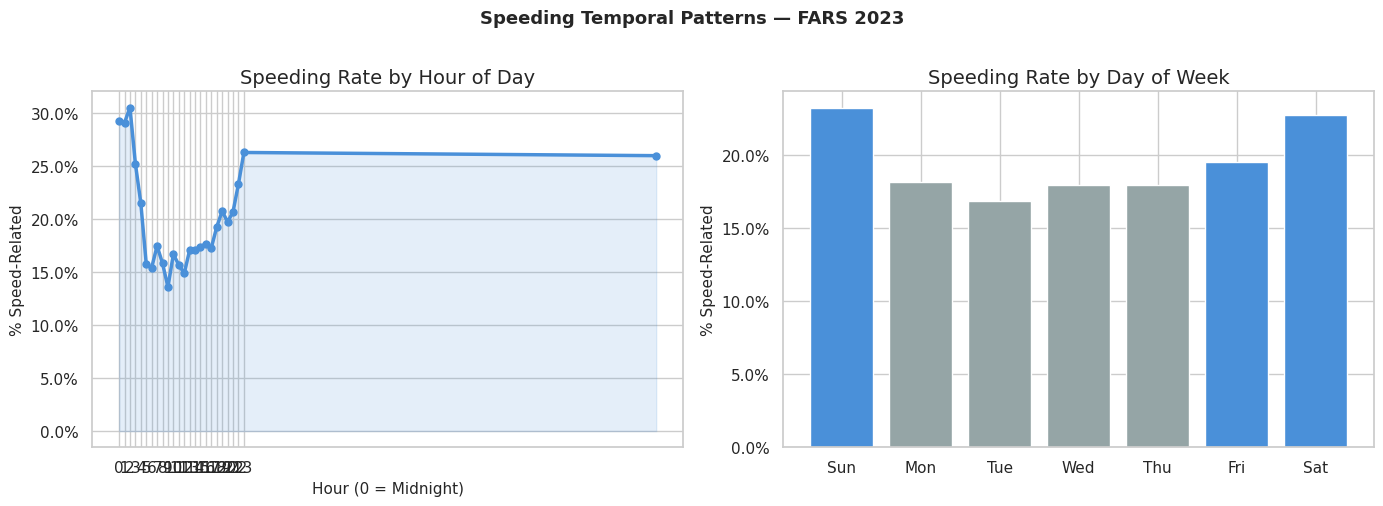

In [ ]:
# ── 5F: Speeding Rate by Hour ─────────────────────────────────────────────────
# Use the correct hour column from the merge
hour_col = 'HOUR' if 'HOUR' in valid_spd.columns else 'HOUR_y'

spd_hour = (
    valid_spd.groupby(hour_col)['IS_SPEEDING']
    .agg(rate='mean', n='count')
    .dropna()
    .query('n >= 10')
    .reset_index()
)
# Rename for plotting consistency
spd_hour.columns = ['HOUR', 'rate', 'n']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speeding by hour
axes[0].plot(spd_hour['HOUR'], spd_hour['rate'] * 100,
             color=COLOR_SPEEDING, linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(spd_hour['HOUR'], spd_hour['rate'] * 100, alpha=0.15, color=COLOR_SPEEDING)
axes[0].set_title('Speeding Rate by Hour of Day')
axes[0].set_xlabel('Hour (0 = Midnight)')
axes[0].set_ylabel('% Speed-Related')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xticks(range(0, 24))

# Speeding by day of week
spd_dow = (
    valid_spd.assign(DOW_LABEL=lambda d: d['DAY_WEEK'].map(dow_map))
    .groupby('DOW_LABEL')['IS_SPEEDING']
    .mean()
    .dropna()
    .reindex(dow_order)
    * 100
)
dow_bar_colors = [COLOR_SPEEDING if d in ['Fri','Sat','Sun'] else COLOR_NEUTRAL for d in dow_order]
axes[1].bar(spd_dow.index, spd_dow.values, color=dow_bar_colors)
axes[1].set_title('Speeding Rate by Day of Week')
axes[1].set_ylabel('% Speed-Related')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Speeding Temporal Patterns — FARS 2023', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 6 — Cross-Target Analysis: Alcohol × Speeding

This section is where our two targets intersect. The concept paper explicitly called out the relationship between alcohol impairment and speeding as a key area of interest — and the data confirms there is a meaningful co-occurrence. Understanding this overlap matters for both modeling (these variables may interact) and policy (joint enforcement strategies).

In [ ]:
# ── Cross-Tab: Alcohol × Speeding ─────────────────────────────────────────────
cross = (
    master
    .dropna(subset=['IS_ALCOHOL_IMPAIRED','IS_SPEEDING'])
    .copy()
)
cross['ALC_BINARY'] = cross['IS_ALCOHOL_IMPAIRED'].astype(int)
cross['SPD_BINARY'] = cross['IS_SPEEDING'].astype(int)

ct = pd.crosstab(cross['SPD_BINARY'], cross['ALC_BINARY'], normalize='index')
print('=== Alcohol Impairment Rate by Speeding Involvement ===')
print('(Row % — reading: of speeding crashes, X% also had alcohol impaired driver)')
print(ct.rename(index={0:'Not Speeding',1:'Speeding'},
                columns={0:'Not Impaired',1:'Impaired'}).to_string())

rate_spd  = ct.loc[1, 1] * 100
rate_nspd = ct.loc[0, 1] * 100
print(f'\nAlcohol rate in SPEEDING crashes:     {rate_spd:.1f}%')
print(f'Alcohol rate in NON-speeding crashes: {rate_nspd:.1f}%')
print(f'Relative risk multiplier:             {rate_spd/rate_nspd:.1f}x')

=== Alcohol Impairment Rate by Speeding Involvement ===
(Row % — reading: of speeding crashes, X% also had alcohol impaired driver)
ALC_BINARY    Not Impaired  Impaired
SPD_BINARY                          
Not Speeding      0.722657  0.277343
Speeding          0.467378  0.532622

Alcohol rate in SPEEDING crashes:     53.3%
Alcohol rate in NON-speeding crashes: 27.7%
Relative risk multiplier:             1.9x


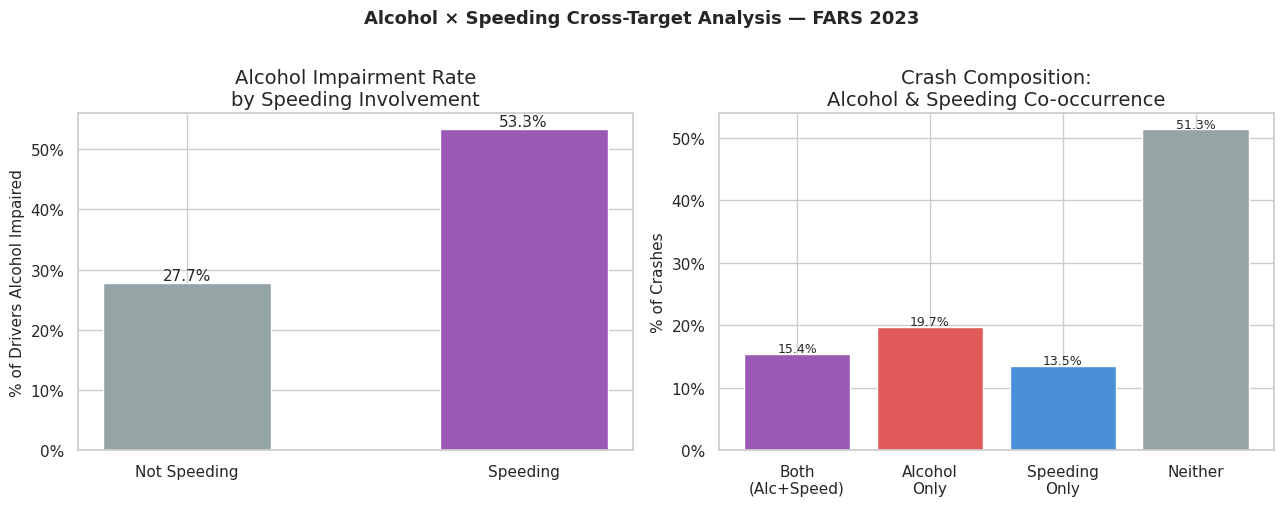

Crashes with BOTH alcohol & speeding: 2996 (15.4% of tested-driver crashes)
This co-occurrence will be included as an interaction term in the logistic regression model.


In [ ]:
# ── Visualize the Cross-Target Overlap ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar: alcohol rate by speeding status
spd_labels = ['Not Speeding', 'Speeding']
alc_rates  = [rate_nspd, rate_spd]
bar_cols   = [COLOR_NEUTRAL, COLOR_BOTH]
axes[0].bar(spd_labels, alc_rates, color=bar_cols, edgecolor='white', width=0.5)
axes[0].set_ylabel('% of Drivers Alcohol Impaired')
axes[0].set_title('Alcohol Impairment Rate\nby Speeding Involvement')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(alc_rates):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

# Stacked bar: composition of speeding vs non-speeding crashes
both       = len(cross[(cross['ALC_BINARY']==1) & (cross['SPD_BINARY']==1)])
alc_only   = len(cross[(cross['ALC_BINARY']==1) & (cross['SPD_BINARY']==0)])
spd_only   = len(cross[(cross['ALC_BINARY']==0) & (cross['SPD_BINARY']==1)])
neither    = len(cross[(cross['ALC_BINARY']==0) & (cross['SPD_BINARY']==0)])
total_ct   = both + alc_only + spd_only + neither

categories = ['Both\n(Alc+Speed)', 'Alcohol\nOnly', 'Speeding\nOnly', 'Neither']
values     = [both, alc_only, spd_only, neither]
colors_ct  = [COLOR_BOTH, COLOR_ALCOHOL, COLOR_SPEEDING, COLOR_NEUTRAL]
axes[1].bar(categories, [v/total_ct*100 for v in values], color=colors_ct, edgecolor='white')
axes[1].set_ylabel('% of Crashes')
axes[1].set_title('Crash Composition:\nAlcohol & Speeding Co-occurrence')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(values):
    axes[1].text(i, v/total_ct*100 + 0.3, f'{v/total_ct*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('Alcohol × Speeding Cross-Target Analysis — FARS 2023',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Crashes with BOTH alcohol & speeding: {both} ({both/total_ct*100:.1f}% of tested-driver crashes)')
print('This co-occurrence will be included as an interaction term in the logistic regression model.')

---
## Summary of EDA Findings

### Alcohol Impairment
| Finding | Detail |
|---------|--------|
| Testing rate | ~35% of drivers in fatal crashes received valid BAC tests |
| Impairment rate | ~34% of tested drivers were at or above the 0.08 g/dL threshold |
| Highest-risk hour | 1 AM (~73% impairment among tested) |
| Lowest-risk hour | Mid-morning (10–11 AM, ~11%) |
| Highest-risk days | Sunday (~49%) and Saturday (~45%) |
| Age risk peak | 20–29 year olds (~45%) and 30–39 (~43%) |
| Sex | Male drivers: ~36% vs. Female: ~26% |
| Lighting | Dark conditions 2–2.5× higher rate than daylight |

### Speeding
| Finding | Detail |
|---------|--------|
| Overall rate | ~18% of crashes in valid records were speed-related |
| Lower-limit paradox | 25–35 mph zones show higher speeding rates than 65–70 mph highways |
| Surface condition | Ice/snow roads show highest speeding involvement (~35–47%) |
| One-way streets | Highest speeding rate by trafficway type |
| Prior violations | Drivers with prior speeding tickets appear in speeding crashes at elevated rates |

### Cross-Target
| Finding | Detail |
|---------|--------|
| Co-occurrence multiplier | Speeding crashes are ~2.5× more likely to also involve an impaired driver |
| Policy implication | Joint enforcement (DUI checkpoints + speed enforcement) targets the highest-risk combination |

---
### Next Steps
- **One-Hot Encoding** will be applied in the modeling notebook for all nominal categorical variables
- **Logistic Regression Model** (separate models per target) will quantify the relative contribution of each variable
- **Random Forest Model**
Handles non-linear relationships and variable interactions without you having to manually specify them. Gives you feature importance rankings useful for saying "here are the top 10 predictors of alcohol impairment." Works well with your mix of nominal and continuous variables post-OHE.
- XGBOOST Model
Typically outperforms Random Forest on tabular data. Also gives feature importance, handles class imbalance better, and is the industry standard for this type of classification problem. Slightly less interpretable than logistic regression but still explainable with tools like SHAP.
- **Interaction terms** (e.g., HOUR × IS_ALCOHOL_IMPAIRED, DAY_WEEK × IS_SPEEDING) will be explored in the modeling phase